---
# Modelos Lineales
---

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from numpy.linalg import inv

df = pd.read_csv("../data/Load/data_sensor_D.csv")
df = df.drop(columns=["periodo", "datetime"]).dropna()

FEATURES = [c for c in df.columns if c != "AQI"]
X = df[FEATURES].values
y = df["AQI"].values

print(f"Shape: {df.shape}")
print(f"Features: {FEATURES}")

Shape: (13616, 10)
Features: ['CO2_ppm', 'CO_ppm', 'SO2_ppm', 'O3_ppm', 'NO2_ppm', 'PM2_5_ugm3', 'temp_C', 'hum_pct', 'Bat_pct']


In [48]:
# Ridge alpha search
Xs = StandardScaler().fit_transform(X)
best_alpha = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5).fit(Xs, y).alpha_
print(f"Ridge best alpha: {best_alpha:.4f}")

pipe_lr    = Pipeline([("sc", StandardScaler()), ("m", LinearRegression())])
pipe_ridge = Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=best_alpha))])

# Cross-validation 5-fold
kf      = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["r2", "neg_mean_squared_error", "neg_mean_absolute_error"]

def cv_summary(pipe, name):
    res  = cross_validate(pipe, X, y, cv=kf, scoring=scoring)
    r2   = res["test_r2"]
    rmse = np.sqrt(-res["test_neg_mean_squared_error"])
    mae  = -res["test_neg_mean_absolute_error"]
    print(f"\n{name}")
    print(f"  R2   {r2.mean():.4f} +/- {r2.std():.4f}")
    print(f"  RMSE {rmse.mean():.4f} +/- {rmse.std():.4f}")
    print(f"  MAE  {mae.mean():.4f} +/- {mae.std():.4f}")
    return r2, rmse, mae

r2_lr,    rmse_lr,    mae_lr    = cv_summary(pipe_lr,    "Linear Regression")
r2_ridge, rmse_ridge, mae_ridge = cv_summary(pipe_ridge, f"Ridge (alpha={best_alpha:.4f})")

pipe_lr.fit(X, y);    yhat_lr    = pipe_lr.predict(X);    res_lr    = y - yhat_lr
pipe_ridge.fit(X, y); yhat_ridge = pipe_ridge.predict(X); res_ridge = y - yhat_ridge

Ridge best alpha: 1668.1005

Linear Regression
  R2   0.4586 +/- 0.0562
  RMSE 0.6798 +/- 0.0365
  MAE  0.5036 +/- 0.0045

Ridge (alpha=1668.1005)
  R2   0.4466 +/- 0.0321
  RMSE 0.6878 +/- 0.0203
  MAE  0.5226 +/- 0.0026


In [49]:
# Model assumptions

# Multicollinearity (VIF)
corr_m = np.corrcoef(Xs.T)
try:
    vif = np.diag(inv(corr_m))
except np.linalg.LinAlgError:
    vif = np.full(X.shape[1], np.nan)

print("VIF:")
for fn, v in zip(FEATURES, vif):
    flag = "OK" if v < 5 else ("MODERATE" if v < 10 else "HIGH")
    print(f"  {fn:<18} {v:.2f}  {flag}")

VIF:
  CO2_ppm            1.72  OK
  CO_ppm             1.80  OK
  SO2_ppm            1.83  OK
  O3_ppm             1.31  OK
  NO2_ppm            2.25  OK
  PM2_5_ugm3         1.21  OK
  temp_C             3.55  OK
  hum_pct            3.31  OK
  Bat_pct            1.26  OK


In [50]:
# Normality, Homoscedasticity, Autocorrelation
for name, yhat, res in [("LR", yhat_lr, res_lr), ("Ridge", yhat_ridge, res_ridge)]:
    print(f"\n[{name}]")
    stat, p = stats.shapiro(res[:5000])
    print(f"  Normality    (Shapiro-Wilk)  p={p:.4f}  {'OK' if p>0.05 else 'NO'}")
    corr, p = stats.spearmanr(yhat, np.abs(res))
    print(f"  Homoscedasticity (Spearman)  p={p:.4f}  {'OK' if p>0.05 else 'NO'}")
    dw = np.sum(np.diff(res)**2) / np.sum(res**2)
    print(f"  Autocorrelation  (DW)        {dw:.4f}   {'OK' if 1.5<dw<2.5 else 'CHECK'}")


[LR]
  Normality    (Shapiro-Wilk)  p=0.0000  NO
  Homoscedasticity (Spearman)  p=0.0000  NO
  Autocorrelation  (DW)        0.4353   CHECK

[Ridge]
  Normality    (Shapiro-Wilk)  p=0.0000  NO
  Homoscedasticity (Spearman)  p=0.0000  NO
  Autocorrelation  (DW)        0.3706   CHECK


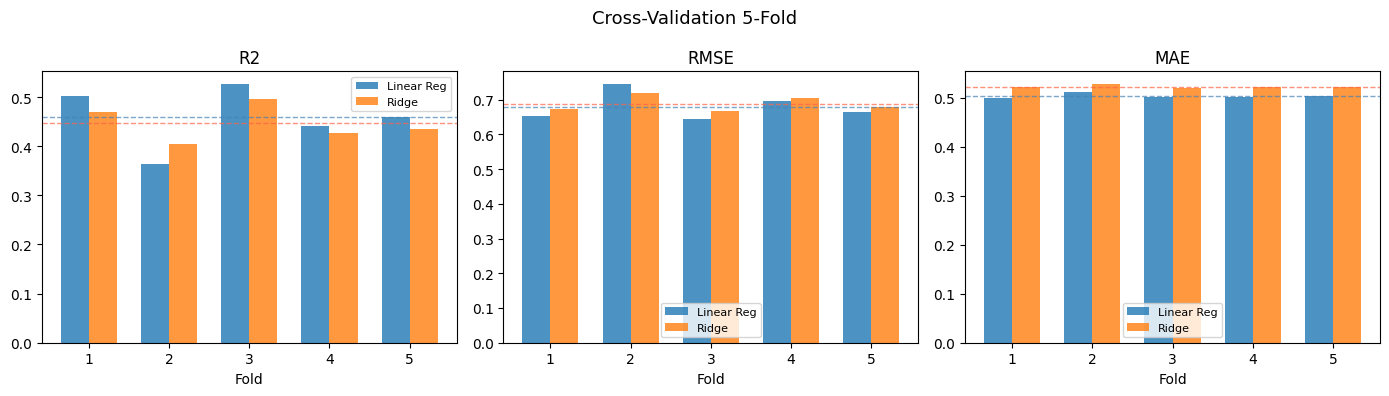

In [51]:
# Fig 1 - CV scores
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Cross-Validation 5-Fold", fontsize=13)
folds = np.arange(1, 6)
w = 0.35
for ax, name, vals_lr, vals_ridge in zip(
    axes,
    ["R2", "RMSE", "MAE"],
    [r2_lr, rmse_lr, mae_lr],
    [r2_ridge, rmse_ridge, mae_ridge]
):
    ax.bar(folds - w/2, vals_lr,    w, label="Linear Reg", alpha=0.8)
    ax.bar(folds + w/2, vals_ridge, w, label="Ridge",      alpha=0.8)
    ax.axhline(vals_lr.mean(),    ls="--", lw=1, color="steelblue", alpha=0.7)
    ax.axhline(vals_ridge.mean(), ls="--", lw=1, color="tomato",    alpha=0.7)
    ax.set_title(name); ax.set_xlabel("Fold"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

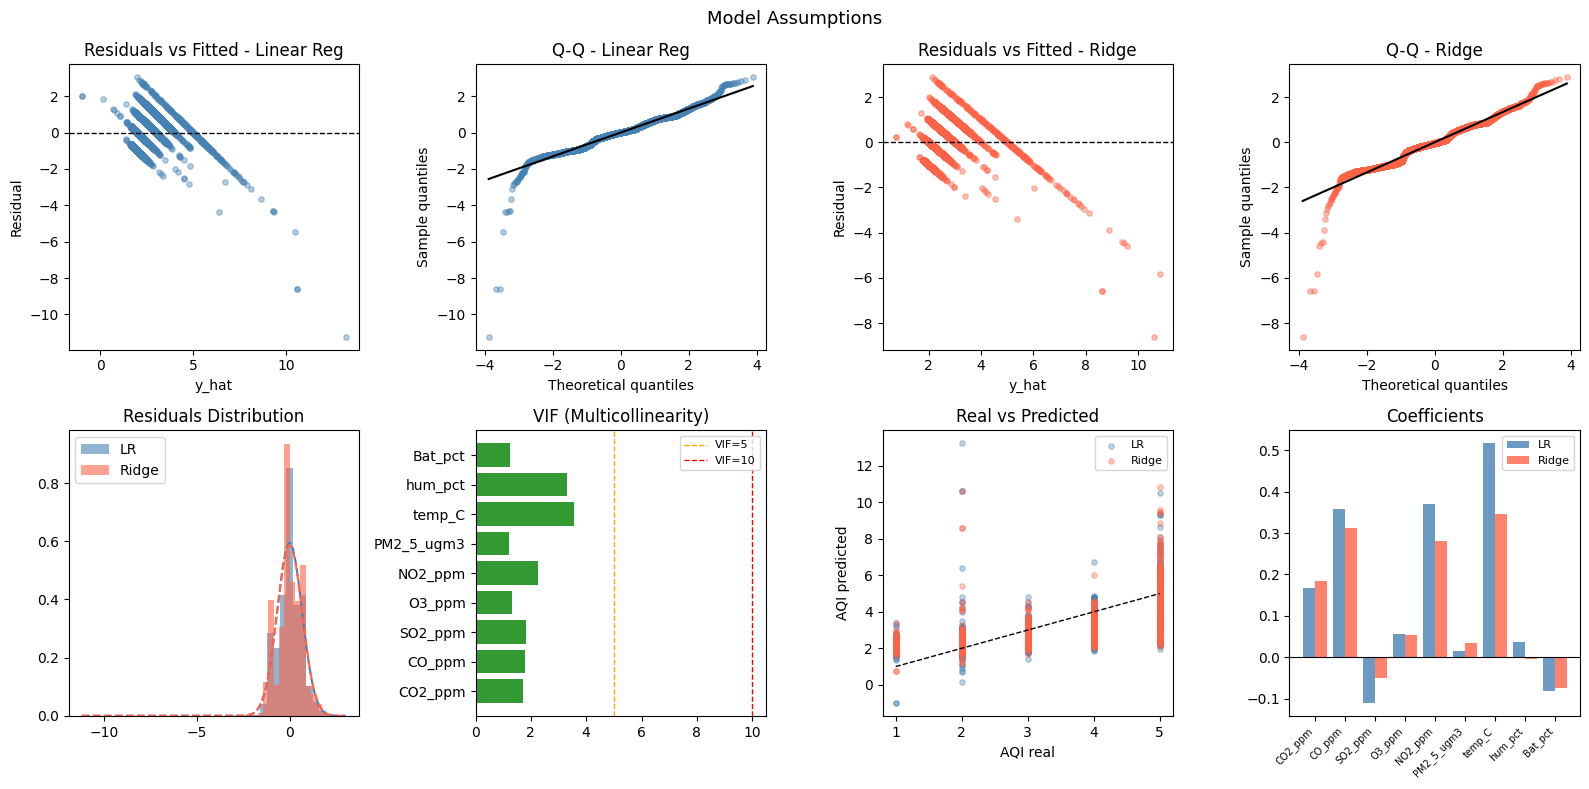

In [52]:
# Fig 2 - Assumptions panel
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Model Assumptions", fontsize=13)

for col, (name, yhat, res, color) in enumerate([
    ("Linear Reg", yhat_lr,    res_lr,    "steelblue"),
    ("Ridge",      yhat_ridge, res_ridge, "tomato"),
]):
    # Residuals vs Fitted
    axes[0, col*2].scatter(yhat, res, alpha=0.4, s=15, color=color)
    axes[0, col*2].axhline(0, color="black", lw=1, ls="--")
    axes[0, col*2].set_title(f"Residuals vs Fitted - {name}")
    axes[0, col*2].set_xlabel("y_hat"); axes[0, col*2].set_ylabel("Residual")

    # Q-Q
    (osm, osr), (slope, intercept, _) = stats.probplot(res, dist="norm")
    axes[0, col*2+1].scatter(osm, osr, alpha=0.4, s=15, color=color)
    line_x = np.array([osm.min(), osm.max()])
    axes[0, col*2+1].plot(line_x, slope*line_x + intercept, color="black", lw=1.5)
    axes[0, col*2+1].set_title(f"Q-Q - {name}")
    axes[0, col*2+1].set_xlabel("Theoretical quantiles"); axes[0, col*2+1].set_ylabel("Sample quantiles")

# Residuals histogram
axes[1, 0].hist(res_lr,    bins=40, alpha=0.6, color="steelblue", density=True, label="LR")
axes[1, 0].hist(res_ridge, bins=40, alpha=0.6, color="tomato",    density=True, label="Ridge")
xr = np.linspace(min(res_lr.min(), res_ridge.min()), max(res_lr.max(), res_ridge.max()), 200)
axes[1, 0].plot(xr, stats.norm.pdf(xr, 0, res_lr.std()),    "--", color="steelblue")
axes[1, 0].plot(xr, stats.norm.pdf(xr, 0, res_ridge.std()), "--", color="tomato")
axes[1, 0].set_title("Residuals Distribution"); axes[1, 0].legend()

# VIF
colors_vif = ["green" if v < 5 else ("orange" if v < 10 else "red") for v in vif]
axes[1, 1].barh(FEATURES, vif, color=colors_vif, alpha=0.8)
axes[1, 1].axvline(5,  color="orange", ls="--", lw=1, label="VIF=5")
axes[1, 1].axvline(10, color="red",    ls="--", lw=1, label="VIF=10")
axes[1, 1].set_title("VIF (Multicollinearity)"); axes[1, 1].legend(fontsize=8)

# Real vs Predicted
axes[1, 2].scatter(y, yhat_lr,    alpha=0.35, s=15, color="steelblue", label="LR")
axes[1, 2].scatter(y, yhat_ridge, alpha=0.35, s=15, color="tomato",    label="Ridge")
diag = [y.min(), y.max()]
axes[1, 2].plot(diag, diag, "k--", lw=1)
axes[1, 2].set_title("Real vs Predicted"); axes[1, 2].set_xlabel("AQI real")
axes[1, 2].set_ylabel("AQI predicted"); axes[1, 2].legend(fontsize=8)

# Coefficients
coef_lr_vals    = pipe_lr["m"].coef_
coef_ridge_vals = pipe_ridge["m"].coef_
x_idx = np.arange(len(FEATURES))
axes[1, 3].bar(x_idx - 0.2, coef_lr_vals,    0.4, label="LR",    color="steelblue", alpha=0.8)
axes[1, 3].bar(x_idx + 0.2, coef_ridge_vals, 0.4, label="Ridge", color="tomato",    alpha=0.8)
axes[1, 3].axhline(0, color="black", lw=0.8)
axes[1, 3].set_xticks(x_idx); axes[1, 3].set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=7)
axes[1, 3].set_title("Coefficients"); axes[1, 3].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Conclusion

Ambos modelos, Regresion Lineal y Ridge, obtuvieron un $R^2$ promedio de alrededor de $0.45$ en la validacion cruzada de $5$ folds, lo cual indica que explican aproximadamente el $45$% de la varianza del AQI. Este desempeno es moderado y sugiere que la relacion entre las variables del sensor y el AQI no es estrictamente lineal, o que hay informacion relevante que los modelos actuales no estan capturando.

Ridge obtuvo un $R^2$ ligeramente menor ($0.447$ vs $0.459$) pero con menor varianza entre folds ($0.032$ vs $0.056$), lo que lo hace mas estable. Sin embargo, ninguno de los dos supera al otro de forma significativa, lo que indica que la regularizacion no resolvio ningun problema estructural importante, algo que tambien confirman los VIF: todas las features tienen valores menores a $5$, por lo que la multicolinealidad no es un problema aqui.

La verificacion de supuestos muestra que ambos modelos fallan en normalidad de residuos y homocedasticidad ($p = 0.000$ en ambos casos), y el estadistico Durbin-Watson de $0.43$ y $0.37$ indica una fuerte autocorrelacion positiva en los residuos. Esto ultimo es especialmente relevante dado que los datos provienen de sensores con mediciones en el tiempo: los errores no son independientes entre si, lo cual viola un supuesto fundamental de la regresion lineal.

En resumen, los modelos lineales sirven como un buen punto de partida, pero los datos presentan caracteristicas (no linealidad aparente, autocorrelacion temporal) que justifican probar enfoques mas flexibles (modelos no lineales).

In [53]:
%reset -f

---
# SVR and XGBRegressor models
---

In [54]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [55]:
data=pd.read_csv("../data/Load/data_sensor_D.csv")
data.head()

,periodo,datetime,CO2_ppm,AQI,CO_ppm,SO2_ppm,O3_ppm,NO2_ppm,PM2_5_ugm3,temp_C,hum_pct,Bat_pct
0,P1,2025-11-06 20:09:35,0.997565,5,0.446300,0.930365,-0.340872,-0.584938,0.443770,0.340532,0.434159,0.704261
1,P1,2025-11-06 20:10:18,0.837793,5,0.358256,1.085778,-0.113082,-0.303829,0.380526,0.338870,0.435463,0.700501
2,P1,2025-11-06 20:11:19,0.651854,4,0.311917,1.085778,-0.204198,-0.491235,0.380526,0.337209,0.432855,0.701754
3,P1,2025-11-06 20:12:19,0.530929,4,0.324274,1.023613,-0.158640,-0.444384,0.317281,0.337209,0.438070,0.703008
4,P1,2025-11-06 20:13:20,0.449070,4,0.284113,1.054696,-0.249756,-0.444384,0.317281,0.332226,0.436767,0.704261


In [56]:
numeric_data=data.drop(columns=["periodo", "datetime"]).copy()
X = numeric_data.drop(columns=["AQI"]).to_numpy()
y = numeric_data["AQI"].to_numpy()

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Suppor vector regression

In [58]:
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.5, epsilon=0.1)
svr_rbf.fit(X_train, y_train)

y_pred_rbf = svr_rbf.predict(X_test)

In [59]:
rmse_rbf = np.sqrt(mean_squared_error(y_test, y_pred_rbf))
mae_rbf = mean_absolute_error(y_test, y_pred_rbf)

print("RBF SVR RMSE:", rmse_rbf)
print("RBF SVR MAE:", mae_rbf)

RBF SVR RMSE: 0.2679739086085002
RBF SVR MAE: 0.18092174667401284


## Gradient boosting decision trees (GBDT): XGBoost

In [60]:
xgb_regressor = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, objective='reg:squarederror')
xgb_regressor.fit(X_train, y_train)

y_pred_xgb = xgb_regressor.predict(X_test)

In [61]:
rmse_rbf = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_rbf = mean_absolute_error(y_test, y_pred_xgb)

print("RBF SVR RMSE:", rmse_rbf)
print("RBF SVR MAE:", mae_rbf)

RBF SVR RMSE: 0.18946211095519447
RBF SVR MAE: 0.0710754245519638


## Hyperparameters selection

In [62]:
xgb_regressor = XGBRegressor()

param_dist = {'n_estimators': [100, 200, 300, 500], 'max_depth': [None, 10, 20, 30, 50], 'learning_rate': [0.1, 0.2, 0.5, 0.8]}

random_search = RandomizedSearchCV(estimator=xgb_regressor, param_distributions=param_dist, n_iter=10, random_state=42, cv=5, scoring='neg_mean_squared_error')

random_search.fit(X_train, y_train)

print(f"Best Params: {random_search.best_params_}")
best_model = random_search.best_estimator_

Best Params: {'n_estimators': 100, 'max_depth': None, 'learning_rate': 0.1}


In [63]:
y_pred_xgb_best = best_model.predict(X_test)

rmse_rbf_best = np.sqrt(mean_squared_error(y_test, y_pred_xgb_best))
mae_rbf_best = mean_absolute_error(y_test, y_pred_xgb_best)

print("RBF SVR RMSE:", rmse_rbf_best)
print("RBF SVR MAE:", mae_rbf_best)

RBF SVR RMSE: 0.19006254554868413
RBF SVR MAE: 0.06895221024751663


In [64]:
%reset -f

---
# Nonlinear Models
---

# About PyTorch

For these models' implementation PyTorch will be used alongside its common structure. For information on in-code structural decisions, check: 
https://docs.pytorch.org/docs/2.12/generated/torch.nn.RNN.html
https://docs.pytorch.org/docs/2.12/generated/torch.nn.Linear.html
https://docs.pytorch.org/docs/2.12/generated/torch.nn.Module.html

# Code
## Libraries

In [73]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [74]:
data = pd.read_csv("../data/Load/data_sensor_D.csv")
data.head()
 

,periodo,datetime,CO2_ppm,AQI,CO_ppm,SO2_ppm,O3_ppm,NO2_ppm,PM2_5_ugm3,temp_C,hum_pct,Bat_pct
0,P1,2025-11-06 20:09:35,0.997565,5,0.446300,0.930365,-0.340872,-0.584938,0.443770,0.340532,0.434159,0.704261
1,P1,2025-11-06 20:10:18,0.837793,5,0.358256,1.085778,-0.113082,-0.303829,0.380526,0.338870,0.435463,0.700501
2,P1,2025-11-06 20:11:19,0.651854,4,0.311917,1.085778,-0.204198,-0.491235,0.380526,0.337209,0.432855,0.701754
3,P1,2025-11-06 20:12:19,0.530929,4,0.324274,1.023613,-0.158640,-0.444384,0.317281,0.337209,0.438070,0.703008
4,P1,2025-11-06 20:13:20,0.449070,4,0.284113,1.054696,-0.249756,-0.444384,0.317281,0.332226,0.436767,0.704261


In [75]:

numeric_data = data.drop(columns=["periodo", "datetime"]).copy()
X = numeric_data.drop(columns=["AQI"]).to_numpy()
y = numeric_data["AQI"].to_numpy()
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [76]:
#Transform and Reshape data

scaler_X = StandardScaler()
scaler_y = StandardScaler()
 
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
 
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [77]:
def to_tensor_3d(X, y):
    """
    Function that turns data into tensors, such that it is compatible
    with PyTorch's RNN API
    """
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)   # (N, 1, F)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)   # (N, 1)
    return TensorDataset(X_t, y_t)

train_ds = to_tensor_3d(X_train_sc, y_train_sc)
test_ds  = to_tensor_3d(X_test_sc,  y_test_sc)
 
BATCH_SIZE = 64


# Considering no sliding window, assuming it is not sequential
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
 

In [78]:
# Generalized, where to store computations? in case user has a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [79]:
# Summarized, to use for both models
INPUT_SIZE  = X_train.shape[1]
HIDDEN_SIZE = 64
NUM_LAYERS  = 2
DROPOUT     = 0.2
EPOCHS      = 100
LR          = 1e-3

## Classes and functions
Generalized for use in other proyects

In [80]:
class VanillaRNN(nn.Module):
    """Single-step regression with a vanilla (Elman) RNN."""
 
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            nonlinearity="tanh",
        )
        self.fc = nn.Linear(hidden_size, 1)
 
    def forward(self, x):
        out, _ = self.rnn(x) # out: (batch, seq, hidden)
        return self.fc(out[:, -1, :]) # last time-step → (batch, 1)

In [81]:
class GRUNet(nn.Module):
    """Single-step regression with a GRU."""
 
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)
 
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [82]:
def train_model(model, loader, epochs=EPOCHS, lr=LR):
    """
    Function that manages and tracks training stage's epochs
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
 
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)
 
        avg_loss = epoch_loss / len(loader.dataset)
        scheduler.step(avg_loss)
 
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{epochs}  loss={avg_loss:.6f}")
 
    return model

In [83]:
def evaluate_model(model, loader, scaler_y):
    """
    Function that predicts and perfurms evaluation metrics for models
    """
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch).cpu().numpy()
            preds.append(out)
            targets.append(y_batch.numpy())
 
    preds   = scaler_y.inverse_transform(np.vstack(preds)).ravel()
    targets = scaler_y.inverse_transform(np.vstack(targets)).ravel()
 
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae  = mean_absolute_error(targets, preds)
    return rmse, mae, preds, targets

In [84]:
# --------------------------------
#           Vanilla RNN
# --------------------------------


print("\n── Vanilla RNN ──────────────────────────────────────────────────────")
rnn_model = VanillaRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
rnn_model = train_model(rnn_model, train_loader)
 
rmse_rnn, mae_rnn, y_pred_rnn, _ = evaluate_model(rnn_model, test_loader, scaler_y)
print(f"Vanilla RNN RMSE: {rmse_rnn:.4f}")
print(f"Vanilla RNN MAE:  {mae_rnn:.4f}")
 

# --------------------------------
#               GRU
# --------------------------------
print("\n── GRU ──────────────────────────────────────────────────────────────")
gru_model = GRUNet(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
gru_model = train_model(gru_model, train_loader)
 
rmse_gru, mae_gru, y_pred_gru, y_true = evaluate_model(gru_model, test_loader, scaler_y)
print(f"GRU RMSE: {rmse_gru:.4f}")
print(f"GRU MAE:  {mae_gru:.4f}")
 



── Vanilla RNN ──────────────────────────────────────────────────────
  Epoch  10/100  loss=0.100537
  Epoch  20/100  loss=0.091852
  Epoch  30/100  loss=0.077795
  Epoch  40/100  loss=0.074134
  Epoch  50/100  loss=0.072588
  Epoch  60/100  loss=0.071133
  Epoch  70/100  loss=0.071233
  Epoch  80/100  loss=0.070322
  Epoch  90/100  loss=0.070135
  Epoch 100/100  loss=0.070109
Vanilla RNN RMSE: 0.2459
Vanilla RNN MAE:  0.1826

── GRU ──────────────────────────────────────────────────────────────
  Epoch  10/100  loss=0.098972
  Epoch  20/100  loss=0.095285
  Epoch  30/100  loss=0.094575
  Epoch  40/100  loss=0.092659
  Epoch  50/100  loss=0.090732
  Epoch  60/100  loss=0.090566
  Epoch  70/100  loss=0.090083
  Epoch  80/100  loss=0.090054
  Epoch  90/100  loss=0.090263
  Epoch 100/100  loss=0.089576
GRU RMSE: 0.2792
GRU MAE:  0.2255


In [85]:
# --------------------------------
#           Summary Metrics
# --------------------------------
print("\n── Results summary ──────────────────────────────────────────────────")
results = pd.DataFrame({
    "Model": ["Vanilla RNN", "GRU"],
    "RMSE":  [rmse_rnn,     rmse_gru],
    "MAE":   [mae_rnn,      mae_gru],
})
print(results.to_string(index=False))


── Results summary ──────────────────────────────────────────────────
      Model     RMSE      MAE
Vanilla RNN 0.245893 0.182631
        GRU 0.279245 0.225537


## Cross Validation GRU Model

GRU Hyperparameter Optimization via K-Fold Cross-Validation. Searches over hidden_size, num_layers, dropout, lr, batch_size using K-Fold CV, then retrains the best config on the full training set. Selected ranges are semi-arbitrary.

In [86]:
import itertools
from sklearn.model_selection import KFold

In [87]:
param_grid = {
    "hidden_size": [32, 64, 128],
    "num_layers":  [1, 2],
    "dropout":     [0.0, 0.2, 0.3],
    "lr":          [1e-3, 5e-4],
    "batch_size":  [32, 64],
}

CV_FOLDS    = 5
CV_EPOCHS   = 50   
RANDOM_SEED = 42


### Helpers in Generalized Form

In [88]:

def make_fold_loaders(X, y, train_idx, val_idx, batch_size):
    """
    Helper Function
    build fold loaders (scale inside fold to avoid leakage)
    idea suggested from Stack Overflow
    """
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    fold_scaler_X = StandardScaler()
    fold_scaler_y = StandardScaler()

    X_tr_sc  = fold_scaler_X.fit_transform(X_tr)
    X_val_sc = fold_scaler_X.transform(X_val)

    y_tr_sc  = fold_scaler_y.fit_transform(y_tr.reshape(-1, 1)).ravel()
    y_val_sc = fold_scaler_y.transform(y_val.reshape(-1, 1)).ravel()

    tr_loader  = DataLoader(to_tensor_3d(X_tr_sc,  y_tr_sc),
                             batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(to_tensor_3d(X_val_sc, y_val_sc),
                             batch_size=batch_size, shuffle=False)
    return tr_loader, val_loader, fold_scaler_y


def train_fold(model, loader, epochs, lr):
    """
    Helper
    single-fold training
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )
    for _ in range(epochs):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)
        scheduler.step(epoch_loss / len(loader.dataset))
    return model

def fold_evaluate(model, loader, fold_scaler_y):
    """
    HELPER 
    RMSE on a validation loader (original scale)
    """
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds.append(model(X_batch).cpu().numpy())
            targets.append(y_batch.numpy())
    preds   = fold_scaler_y.inverse_transform(np.vstack(preds)).ravel()
    targets = fold_scaler_y.inverse_transform(np.vstack(targets)).ravel()
    return np.sqrt(mean_squared_error(targets, preds))


### CV Applied

In [89]:

keys   = list(param_grid.keys())
combos = list(itertools.product(*param_grid.values())) # taken from Claude
kf     = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

print(f"Total combinations : {len(combos)}")
print(f"Folds              : {CV_FOLDS}")
print(f"Total training runs: {len(combos) * CV_FOLDS}\n")


Total combinations : 72
Folds              : 5
Total training runs: 360



In [90]:

cv_results = []

for i, combo in enumerate(combos):
    params     = dict(zip(keys, combo))
    fold_rmses = []

    for tr_idx, val_idx in kf.split(X_train):
        tr_loader, val_loader, fold_sy = make_fold_loaders(
            X_train, y_train, tr_idx, val_idx, params["batch_size"]
        )
        model = GRUNet(
            input_size  = INPUT_SIZE,
            hidden_size = params["hidden_size"],
            num_layers  = params["num_layers"],
            dropout     = params["dropout"],
        )
        model = train_fold(model, tr_loader, CV_EPOCHS, params["lr"])
        fold_rmses.append(fold_evaluate(model, val_loader, fold_sy))

    mean_rmse = float(np.mean(fold_rmses))
    std_rmse  = float(np.std(fold_rmses))
    cv_results.append({**params, "mean_rmse": mean_rmse, "std_rmse": std_rmse})

    print(f"[{i+1:3d}/{len(combos)}] {params}  →  "
          f"RMSE = {mean_rmse:.4f} ± {std_rmse:.4f}")


[  1/72] {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32}  →  RMSE = 0.2755 ± 0.0010
[  2/72] {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 64}  →  RMSE = 0.2764 ± 0.0006
[  3/72] {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.0005, 'batch_size': 32}  →  RMSE = 0.2778 ± 0.0015
[  4/72] {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.0005, 'batch_size': 64}  →  RMSE = 0.2796 ± 0.0008
[  5/72] {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32}  →  RMSE = 0.2749 ± 0.0005
[  6/72] {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 64}  →  RMSE = 0.2766 ± 0.0017
[  7/72] {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 32}  →  RMSE = 0.2771 ± 0.0007
[  8/72] {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 64}  →  RMSE = 0.2786 ± 0.0005
[  9/72] {'hidden_size': 32, 'num_la

### Results

In [91]:

results_df = (pd.DataFrame(cv_results)
                .sort_values("mean_rmse")
                .reset_index(drop=True))

print(results_df.head(3).to_string(index=False))


best = results_df.iloc[0]
print("\n ***** Best hyperparameters **************************")
print(best.to_string())


 hidden_size  num_layers  dropout    lr  batch_size  mean_rmse  std_rmse
         128           2      0.2 0.001          32   0.196245  0.010818
         128           2      0.0 0.001          32   0.200841  0.008567
         128           2      0.3 0.001          32   0.217057  0.030407

 ***** Best hyperparameters **************************
hidden_size    128.000000
num_layers       2.000000
dropout          0.200000
lr               0.001000
batch_size      32.000000
mean_rmse        0.196245
std_rmse         0.010818


## Train GRU with best hyperparameters

In [92]:
best_gru = GRUNet(
    input_size  = INPUT_SIZE,
    hidden_size = int(best["hidden_size"]),
    num_layers  = int(best["num_layers"]),
    dropout     = float(best["dropout"]),
)

best_train_loader = DataLoader(
    train_ds, batch_size=int(best["batch_size"]), shuffle=True
)

print("\nRetraining best GRU on the full training set …")
best_gru = train_model(best_gru, best_train_loader,
                        epochs=EPOCHS, lr=float(best["lr"]))

rmse_best, mae_best, _, _ = evaluate_model(best_gru, test_loader, scaler_y)
print(f"\nBest GRU (CV-tuned)  RMSE : {rmse_best:.4f}")
print(f"Best GRU (CV-tuned)  MAE  : {mae_best:.4f}")


Retraining best GRU on the full training set …
  Epoch  10/100  loss=0.096658
  Epoch  20/100  loss=0.092530
  Epoch  30/100  loss=0.057348
  Epoch  40/100  loss=0.044024
  Epoch  50/100  loss=0.042238
  Epoch  60/100  loss=0.040936
  Epoch  70/100  loss=0.039964
  Epoch  80/100  loss=0.039101
  Epoch  90/100  loss=0.036378
  Epoch 100/100  loss=0.035725

Best GRU (CV-tuned)  RMSE : 0.1838
Best GRU (CV-tuned)  MAE  : 0.0723


In [93]:
# Compare with baseline GRU
print(f"\nBaseline GRU         RMSE : {rmse_gru:.4f}")
print(f"Baseline GRU         MAE  : {mae_gru:.4f}")


Baseline GRU         RMSE : 0.2792
Baseline GRU         MAE  : 0.2255


In [65]:
%reset -f

---
# Best Model
---

In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

data = pd.read_csv("../data/Load/data_sensor_D.csv")
numeric_data = data.drop(columns=["periodo", "datetime"]).copy()
X = numeric_data.drop(columns=["AQI"]).to_numpy()
y = numeric_data["AQI"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [67]:
param_dist = {'n_estimators': [100, 200, 300, 500],
              'max_depth': [None, 10, 20, 30, 50],
              'learning_rate': [0.1, 0.2, 0.5, 0.8]}
rs = RandomizedSearchCV(XGBRegressor(), param_dist, n_iter=10, random_state=42,
                        cv=5, scoring='neg_mean_squared_error')
rs.fit(X_train, y_train)
yhat_xgb = rs.best_estimator_.predict(X_test)
print(f"XGBoost best params: {rs.best_params_}")

XGBoost best params: {'n_estimators': 100, 'max_depth': None, 'learning_rate': 0.1}


In [69]:
device = torch.device("cpu")

def to_tensor_3d(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    )

class GRUNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

train_loader = DataLoader(to_tensor_3d(X_train_sc, y_train_sc), batch_size=32, shuffle=True)
test_loader  = DataLoader(to_tensor_3d(X_test_sc,  y_test_sc),  batch_size=32, shuffle=False)

best_gru = GRUNet(input_size=X_train.shape[1], hidden_size=128, num_layers=2, dropout=0.2)
best_gru.to(device)

optimizer = torch.optim.Adam(best_gru.parameters(), lr=0.001)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

for epoch in range(1, 101):
    best_gru.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(best_gru(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(best_gru.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    scheduler.step(epoch_loss / len(train_loader.dataset))
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d}/100  loss={epoch_loss/len(train_loader.dataset):.6f}")

best_gru.eval()
preds, targets = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds.append(best_gru(X_batch.to(device)).cpu().numpy())
        targets.append(y_batch.numpy())

yhat_gru = scaler_y.inverse_transform(np.vstack(preds)).ravel()
y_true   = scaler_y.inverse_transform(np.vstack(targets)).ravel()

  Epoch  10/100  loss=0.095802
  Epoch  20/100  loss=0.092719
  Epoch  30/100  loss=0.059566
  Epoch  40/100  loss=0.045521
  Epoch  50/100  loss=0.041448
  Epoch  60/100  loss=0.040563
  Epoch  70/100  loss=0.037245
  Epoch  80/100  loss=0.036143
  Epoch  90/100  loss=0.034890
  Epoch 100/100  loss=0.034473


In [70]:
results = pd.DataFrame({
    "Model": ["XGBoost (tuned)", "GRU (CV-tuned)"],
    "RMSE":  [np.sqrt(mean_squared_error(y_test, yhat_xgb)),
              np.sqrt(mean_squared_error(y_true, yhat_gru))],
    "MAE":   [mean_absolute_error(y_test, yhat_xgb),
              mean_absolute_error(y_true, yhat_gru)],
}).sort_values("RMSE").reset_index(drop=True)

print(results.to_string(index=False, float_format="{:.4f}".format))

          Model   RMSE    MAE
 GRU (CV-tuned) 0.1827 0.0713
XGBoost (tuned) 0.1901 0.0690


## Comparación Final de Modelos

Se entrenaron y evaluaron dos modelos no lineales sobre el conjunto de prueba (20% de los datos).

El GRU con hiperparámetros optimizados por validación cruzada obtuvo el menor RMSE (0.1827), superando a XGBoost en ese métrico. Sin embargo, XGBoost presenta un MAE ligeramente menor (0.0690 vs 0.0713), lo que indica que en promedio comete errores absolutos más pequeños.

La diferencia entre ambos modelos es marginal, por lo que la elección depende de la prioridad:

- Si se busca **minimizar errores grandes** (penalización cuadrática) → **GRU CV-tuned**.
- Si se busca **menor error promedio absoluto** y mayor interpretabilidad → **XGBoost tuned**.

En términos prácticos, ambos modelos representan una mejora sustancial respecto a los modelos lineales (RMSE ~0.68) y al SVR (RMSE ~0.27), confirmando que la relación entre las variables del sensor y el AQI tiene una componente no lineal significativa que los modelos de mayor capacidad logran capturar.